### Changes in this Notebook:

1. Global Perturbation - A slow-moving low-amplitude modulatory signal --> applied to every node
2. Local Perturbation - A Ramp Function/Pulse Function --> applied to Node 1 only


In [1]:
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import special
from scipy.stats import norm
from scipy.stats import pearsonr
from scipy import signal
from scipy.fft import fftshift

import networkx as nx

%matplotlib inline
plt.style.use('seaborn-bright')

C:\Users\kgaya\AppData\Local\Temp\ipykernel_9396\1392457155.py:17: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-bright')


In [2]:
# Setting paths
results_dir = "./SVLargeScaleNetwork_v3_2_results"
os.makedirs(results_dir, exist_ok = True)

sub_dir = sorted(os.listdir(results_dir))
if len(sub_dir) == 0:
    exp_no = 1
else:
    exp_no = int(sub_dir[-1].split('_')[-1]) + 1

write_json = {}

results_dir = os.path.join(results_dir, f'E_{exp_no:02d}')
os.makedirs(results_dir, exist_ok = True)

In [3]:
# (1) Connectivity and Inputs

write_json['T'] = T = 50000   # Time scale (au)
write_json['dt'] = dt = 0.1    # Integration time step
write_json['N'] = N = 3       # Network size
pop_size = 1000 # Subpopulation size TODO: Should this be varied for different nodes as well?

gamma = 0.016       # Conversion parameter to mV
wee = 1.6 / gamma   # E -> E subpopulation synaptic weight  
wei = 3 / gamma     # I -> E subpopulation synaptic weight
wie = -4.7 / gamma  # E -> I subpopulation synaptic weight
wii = -0.13 / gamma # I -> I subpopulation synaptic weight
tau_e = 1           # Time scale for E subpopulation
tau_i = 1 / 2       # Time scale for I subpopulation

beta = 300 * gamma  # slope of firing function

e_bias = -0.25 / gamma  # Bias for E subpopulation
i_bias = -0.5 / gamma   # Bias for I subpopulation

In [4]:
# Defining the Meso-Scale Network (Random Network)

write_json['rho'] = rho = 1             # Connectivity prob
prop = 0.8          # subpopulation proportion
write_json['K_l'] = K_l = 0.08      # lower limit of coupling strength
write_json['K_u'] = K_u = 0.2       # upper limit of coupling strength 

# Setting the coupling coefficients
K = 0.01 * np.ones((N, N))

A = np.zeros((N, N))            # Setting the Adjacency Matrix
A[np.triu_indices(N, 1)] = np.random.binomial(n = 1, p = rho, size = N * (N - 1) // 2)
A[np.tril_indices(N, -1)] = A[np.triu_indices(N, 1)]

W = np.multiply(A, K)                                   # Effective Coupling Matrix
print("Coupling Matrix:\n", W)

Coupling Matrix:
 [[0.   0.01 0.01]
 [0.01 0.   0.01]
 [0.01 0.01 0.  ]]


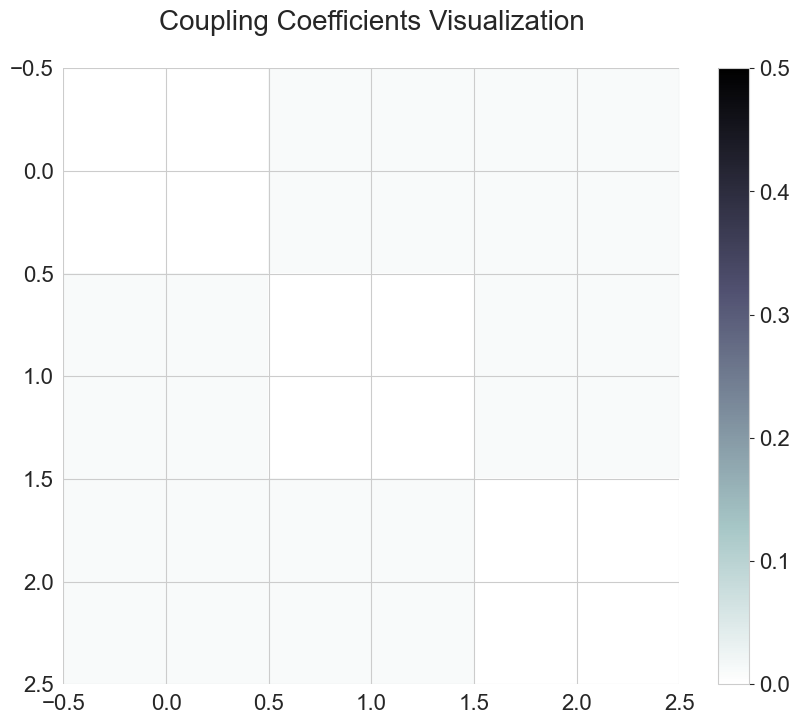

In [5]:
plt.figure(figsize=(10, 8))
plt.rcParams.update({'font.size': 16})
plt.imshow(W, cmap='bone_r',vmin=0,vmax=0.5)
for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
plt.title('Coupling Coefficients Visualization\n', fontsize=20)
plt.colorbar()
plt.show()

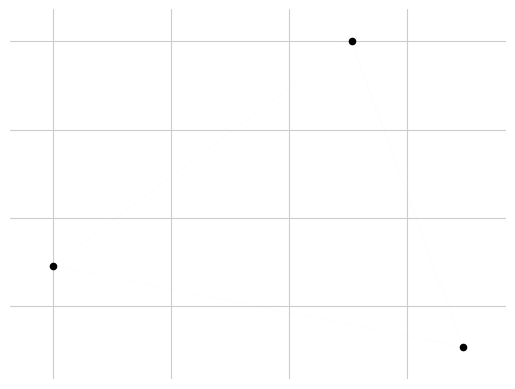

In [6]:
# Graph representation

G = nx.from_numpy_array(W)
G.edges(data=True)
pos = nx.spring_layout(G, seed=7)  # random positions nodes

# nodes
nx.draw_networkx_nodes(G, pos, node_size=20, node_color='black')

# Excitatory coupling
e_ex = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] > 0]
edges_ex = tuple(e_ex)
weights_ex = tuple([G[e][f]['weight'] for e,f in edges_ex]) 

# Inhibitory coupling
e_in = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] < 0]
edges_in = tuple(e_in)
weights_in = tuple([G[e][f]['weight'] for e,f in edges_in]) 

# edges
nx.draw_networkx_edges(G, pos, edgelist=e_ex, width=weights_ex, alpha=1.0, edge_color="green")
nx.draw_networkx_edges(G, pos, edgelist=e_in, width=weights_in, alpha=1.0, edge_color="blue")

for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
plt.show()

In [7]:
# Environmental perturbations

# (1) Slow-Moving Modulating Signal

write_json['N0'] = Noise = 0.05    # TODO: Change this is have low and high amplitude modulating signals

perturbations_1 = np.zeros(T)
filtered_noise_1 = np.zeros(T)
filtered_noise_2 = np.zeros(T)
filtered_noise_3 = np.zeros(T)

for t in range(T - 1):
  perturbations_1[t + 1] = perturbations_1[t] + dt * (-perturbations_1[t] + filtered_noise_1[t])
  filtered_noise_1[t + 1] = filtered_noise_1[t] + dt * 0.1 * (-filtered_noise_1[t] + filtered_noise_2[t])
  filtered_noise_2[t + 1] = filtered_noise_2[t] + dt * 0.1 * (-filtered_noise_2[t] + filtered_noise_3[t])
  filtered_noise_3[t + 1] = filtered_noise_3[t] + dt * -filtered_noise_3[t] \
                            + np.sqrt(2 * Noise * dt) * np.random.normal(0, 1)
  
# (2) Pulse Modulating Signal
write_json['Pulse_period'] = period = 2500
write_json['Pulse_tau'] = tau = 1000
write_json['Pulse_amp'] = pulse_amp = 0.3

perturbations_2 = np.zeros(T)
pulse_count = 0
for t in range(T):
    pulse_count += 1
    if pulse_count <= tau:
        perturbations_2[t] = pulse_amp
    if pulse_count == period:
        pulse_count = 0

perturbations_2 -= (pulse_amp / 2)

# (3) Linear Modulating Signal
perturbations_3 = np.zeros(T)

for t in range(T):
    perturbations_3[t] = (t / T) * 0.5

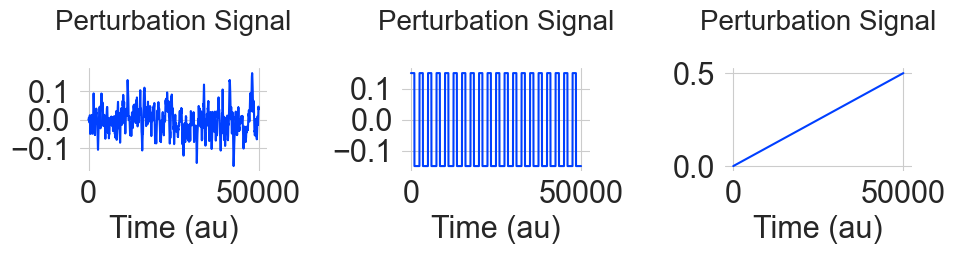

In [8]:
plt.figure(figsize=(10,3))
plt.rcParams.update({'font.size': 22})

plt.subplot(1, 3, 1)
plt.plot(np.arange(0, T), perturbations_1)
for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
plt.title('Perturbation Signal\n', fontsize=20)
plt.xlabel('Time (au)')

plt.subplot(1, 3, 2)
plt.plot(np.arange(0, T), perturbations_2)
for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
plt.title('Perturbation Signal\n', fontsize=20)
plt.xlabel('Time (au)')

plt.subplot(1, 3, 3)
plt.plot(np.arange(0, T), perturbations_3)
for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
plt.title('Perturbation Signal\n', fontsize=20)
plt.xlabel('Time (au)')

plt.tight_layout()
plt.show()

In [9]:
# Setting heterogeneity parameters for nodes (Gamma Distribution)

# Shape and scale parameters for excitatory heterogeneity sampling
write_json['k_e'] = k_e = 2.5           
write_json['theta_e'] = theta_e = 3     

# Shape and scale parameters for inhibitory heterogeneity sampling
write_json['k_i'] = k_i = 4
write_json['theta_e'] = theta_i = 3

sigma_e = np.zeros(N)
sigma_i = np.zeros(N)

for i in range(N):
    sigma_e[i] = np.random.gamma(k_e, theta_e, 1)
for i in range(N):
    sigma_i[i] = np.random.gamma(k_i, theta_i, 1)

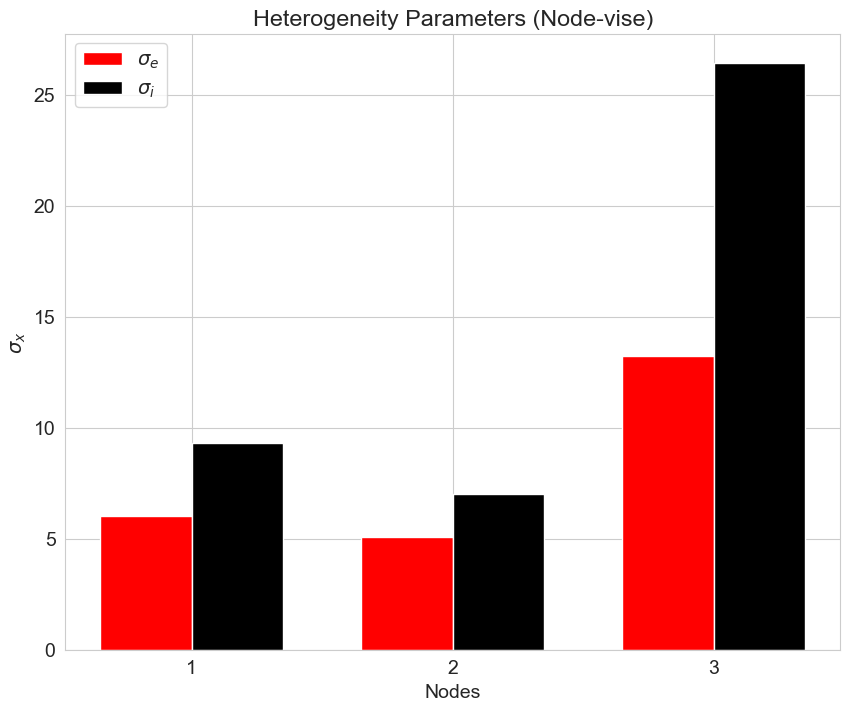

$\sigma_e$ ::  [ 6.00475087  5.07159733 13.2427896 ]
$\sigma_i$ ::  [ 9.30222879  7.01979734 26.4284417 ]


In [10]:
fig_path = os.path.join(results_dir, f"N={N}_heterogeneity_parameters.png")
# Set the positions of the bars on the X-axis
x = np.arange(N)

# Width of the bars
width = 0.35

plt.figure(figsize=(10, 8))
plt.rcParams.update({'font.size': 14})

plt.bar(x - width/2, sigma_e, width, color = 'red', label = r'$\sigma_e$')
plt.bar(x + width/2, sigma_i, width, color = 'black', label = r'$\sigma_i$')
plt.ylabel(r'$\sigma_x$'); plt.xlabel('Nodes')
plt.title("Heterogeneity Parameters (Node-vise)")
plt.xticks(x, x + 1); plt.legend()
plt.savefig(fig_path, dpi = 600)
plt.show()

print(r"$\sigma_e$ :: ", sigma_e)
print(r"$\sigma_i$ :: ", sigma_i)

C:\Users\kgaya\AppData\Local\Temp\ipykernel_9396\490603045.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sigma_e, kde=True, bins=20, hist=False)
C:\Users\kgaya\AppData\Local\Temp\ipykernel_9396\490603045.py:16: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sigma_i, kde=Tr

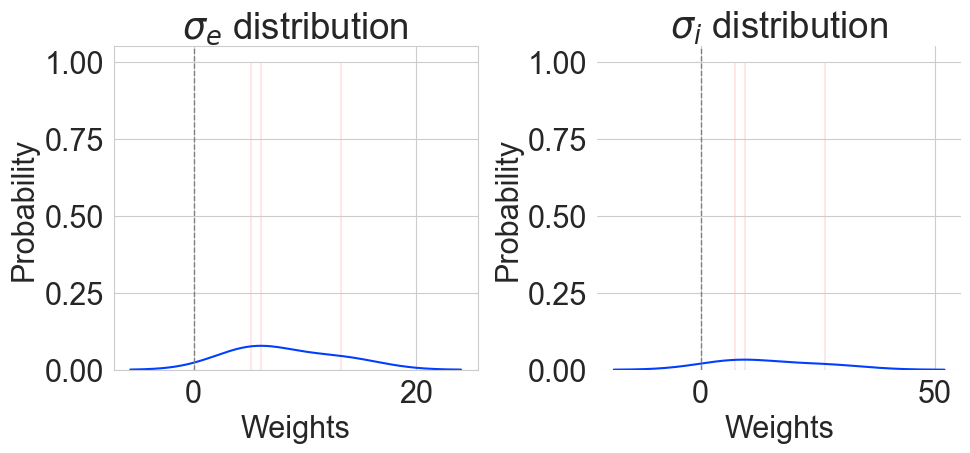

In [11]:
plt.figure(figsize=(10, 5))
plt.rcParams.update({'font.size': 22})

plt.subplot(1, 2, 1)
sns.distplot(sigma_e, kde=True, bins=20, hist=False)
_, _, bars = plt.hist(sigma_e, bins = 100, color="blue",alpha=0.25)
for bar in bars:
    if bar.get_x() > 0:
        bar.set_facecolor("red")
plt.axvline(x=0, linestyle='--',linewidth=1, color='grey')
plt.xlabel('Weights')
plt.ylabel('Probability')
plt.title(r"$\sigma_e$ distribution")

plt.subplot(1, 2, 2)
sns.distplot(sigma_i, kde=True, bins=20, hist=False)
_, _, bars = plt.hist(sigma_i, bins = 100, color="blue",alpha=0.25)
for bar in bars:
    if bar.get_x() > 0:
        bar.set_facecolor("red")
plt.axvline(x=0, linestyle='--',linewidth=1, color='grey')
plt.xlabel('Weights')
plt.ylabel('Probability')
plt.title(r"$\sigma_i$ distribution")

for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
plt.tight_layout()
plt.show()

In [12]:
# resonse function of neurons
def f(x, beta, thresh):
    return 1 / (1 + np.exp(-beta * (x - thresh)))

def F(x, beta, thresh, gamma, sig):
    vmin = -1 / gamma; vmax = 1 / gamma; nsteps = 1000
    dv = np.abs(vmax - vmin) / nsteps
    v = np.arange(vmin, vmax, dv)

    if type(x) == np.ndarray and len(x.shape) == 4:
        x = np.repeat(x[:, :, :, :, np.newaxis], nsteps, axis=4)
    sigmoid_vals = f(x + v, beta, thresh)
    normal_vals = np.exp(-v ** 2 / (2 * sig ** 2)) / np.sqrt(2 * np.pi * sig ** 2)

    return np.sum(dv * sigmoid_vals * normal_vals, axis=-1)

In [13]:
# (2) Network Dynamics

ue = np.zeros((N, T))
ui = np.zeros((N, T))
write_json['D0'] = D = 0.000 / (gamma ** 2)

# TODO: Can we have heterogeneity in mean firing thresh for each population?
thresh_e_sig = 0.0      # mean firing threshold for E-subpopulation
thresh_i_sig = 0.0      # mean firing threshold for I-subpopulation

thresh_e = np.zeros(N)
thresh_i = np.zeros(N)

#Euler integration
for i in range(N):
  ue[i][0] = 0.05 * np.random.normal(0, 1)
  ui[i][0] = 0.05 * np.random.normal(0, 1)
  
  thresh_e[i] = np.sqrt(thresh_e_sig) * np.random.normal(0,1)
  thresh_i[i] = np.sqrt(thresh_i_sig) * np.random.normal(0,1)

for t in range(T - 1):
  for i in range(N):
    _sum_i = 0
    _sum_e = np.matmul(W[i, :], ue[:, t])
    
    _sum_e += perturbations_1[t] / gamma
    
    if (i == 0):
        _sum_e += perturbations_3[t] / gamma
    
    _sum_e += wee * F(ue[i][t], beta, thresh_e[i], gamma, sigma_e[i]) + wie * F(ui[i][t], beta, thresh_i[i], gamma, sigma_i[i])
    ue[i][t + 1] = ue[i][t] + dt / tau_e * (-ue[i][t] + _sum_e + e_bias) + np.sqrt(2 * D * dt / tau_e) * np.random.normal(0, 1)
    
    _sum_i += wei * F(ue[i][t], beta, thresh_e[i], gamma, sigma_e[i]) + wii * F(ui[i][t], beta, thresh_i[i], gamma, sigma_i[i])
    ui[i][t + 1] = ui[i][t] + dt / tau_i * (-ui[i][t] + _sum_i + i_bias) + np.sqrt(2 * D * dt / tau_i) * np.random.normal(0, 1)

C:\Users\kgaya\AppData\Local\Temp\ipykernel_9396\3118493370.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * (x - thresh)))


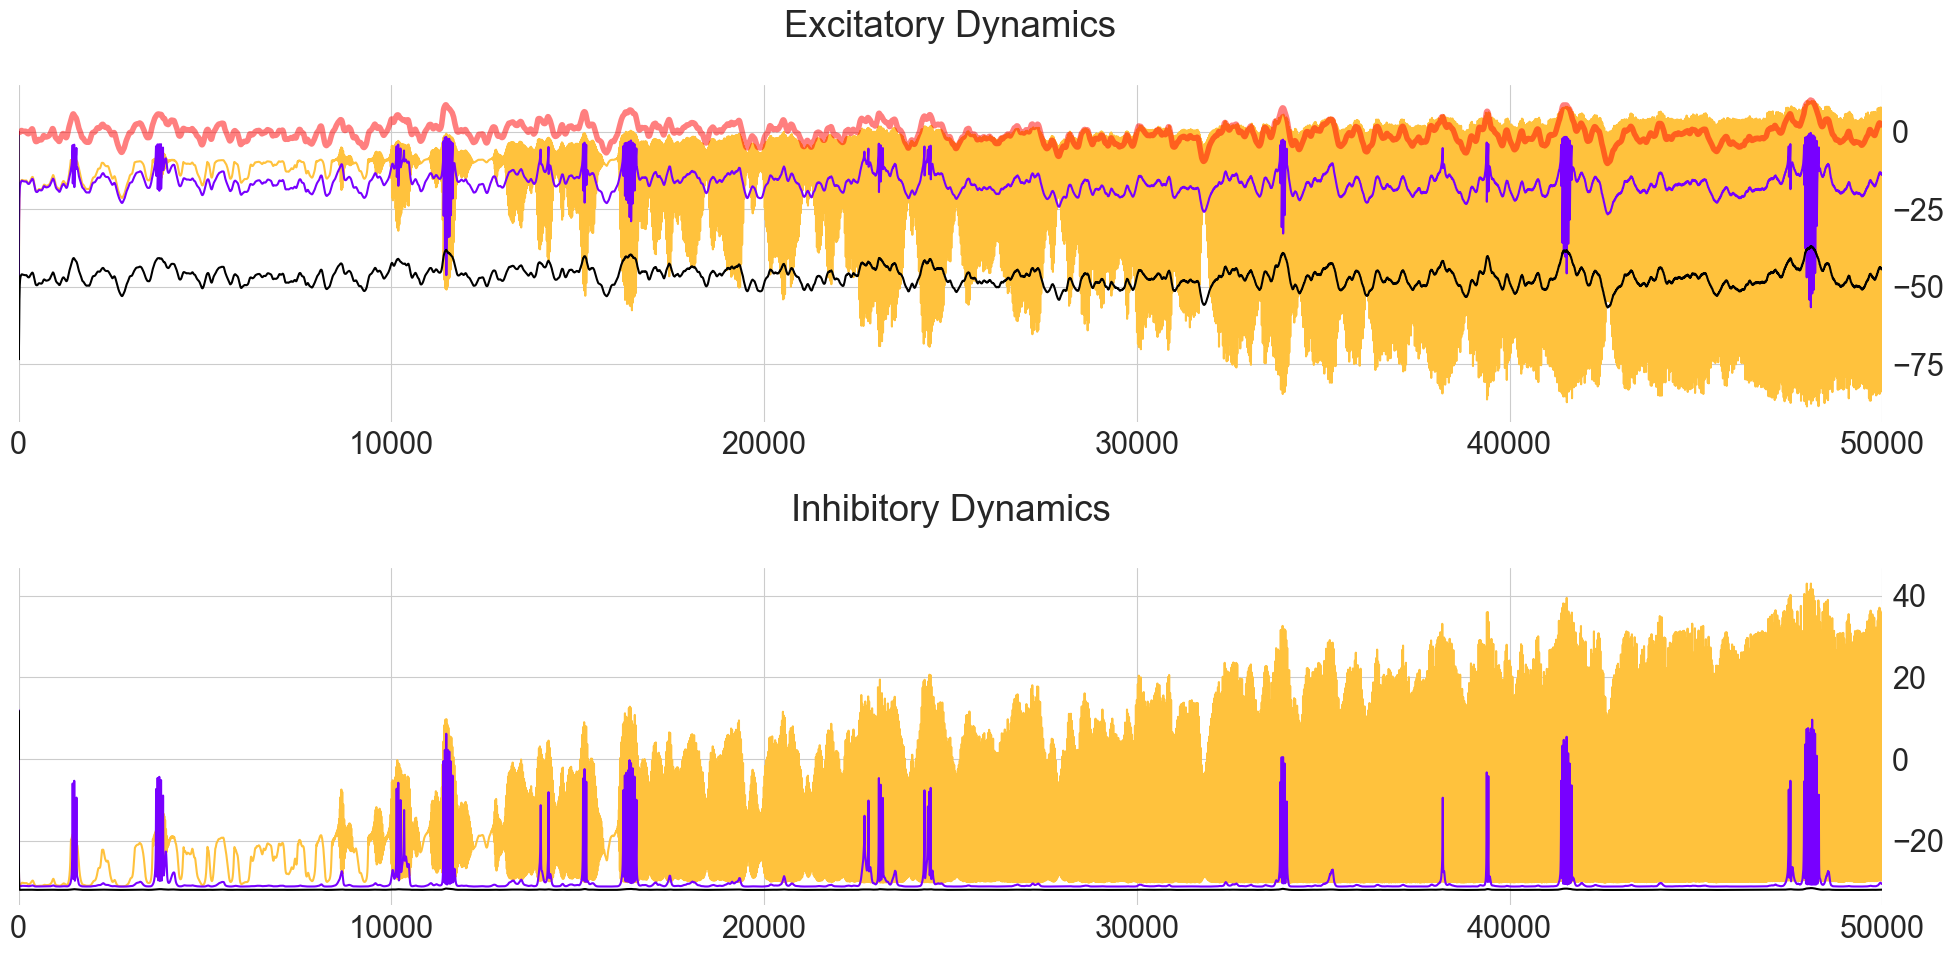

In [14]:
# (3) Visualization in time and Lyapunov exponents

time = np.arange(0, T, 1)

plt.figure(figsize=(20,10))
plt.subplot(2, 1, 1)
colormap = plt.cm.gist_ncar
plt.rcParams.update({'font.size': 22})
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.gnuplot2_r(np.linspace(0.2, 1, N))))
for i in range(N):
    plt.plot(time, ue[i][:], label = f'Node {i+1:01d}')

plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
plt.plot(time, perturbations_1 / gamma, color='red',  linewidth=4, alpha=0.5, label = 'S(t)')
for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
# plt.legend(loc = 'lower left', fontsize=20)
plt.xlim(0, T)
plt.title('Excitatory Dynamics\n')

plt.subplot(2, 1, 2)
plt.rcParams.update({'font.size': 22})
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.gnuplot2_r(np.linspace(0.2, 1, N))))
for i in range(N):
    plt.plot(time, ui[i][:], label = f'Node {i+1:01d}')

plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
# plt.legend(loc = 'lower left', fontsize=20)
plt.xlim(0, T)
plt.title('Inhibitory Dynamics\n')

plt.tight_layout()
plt.show()

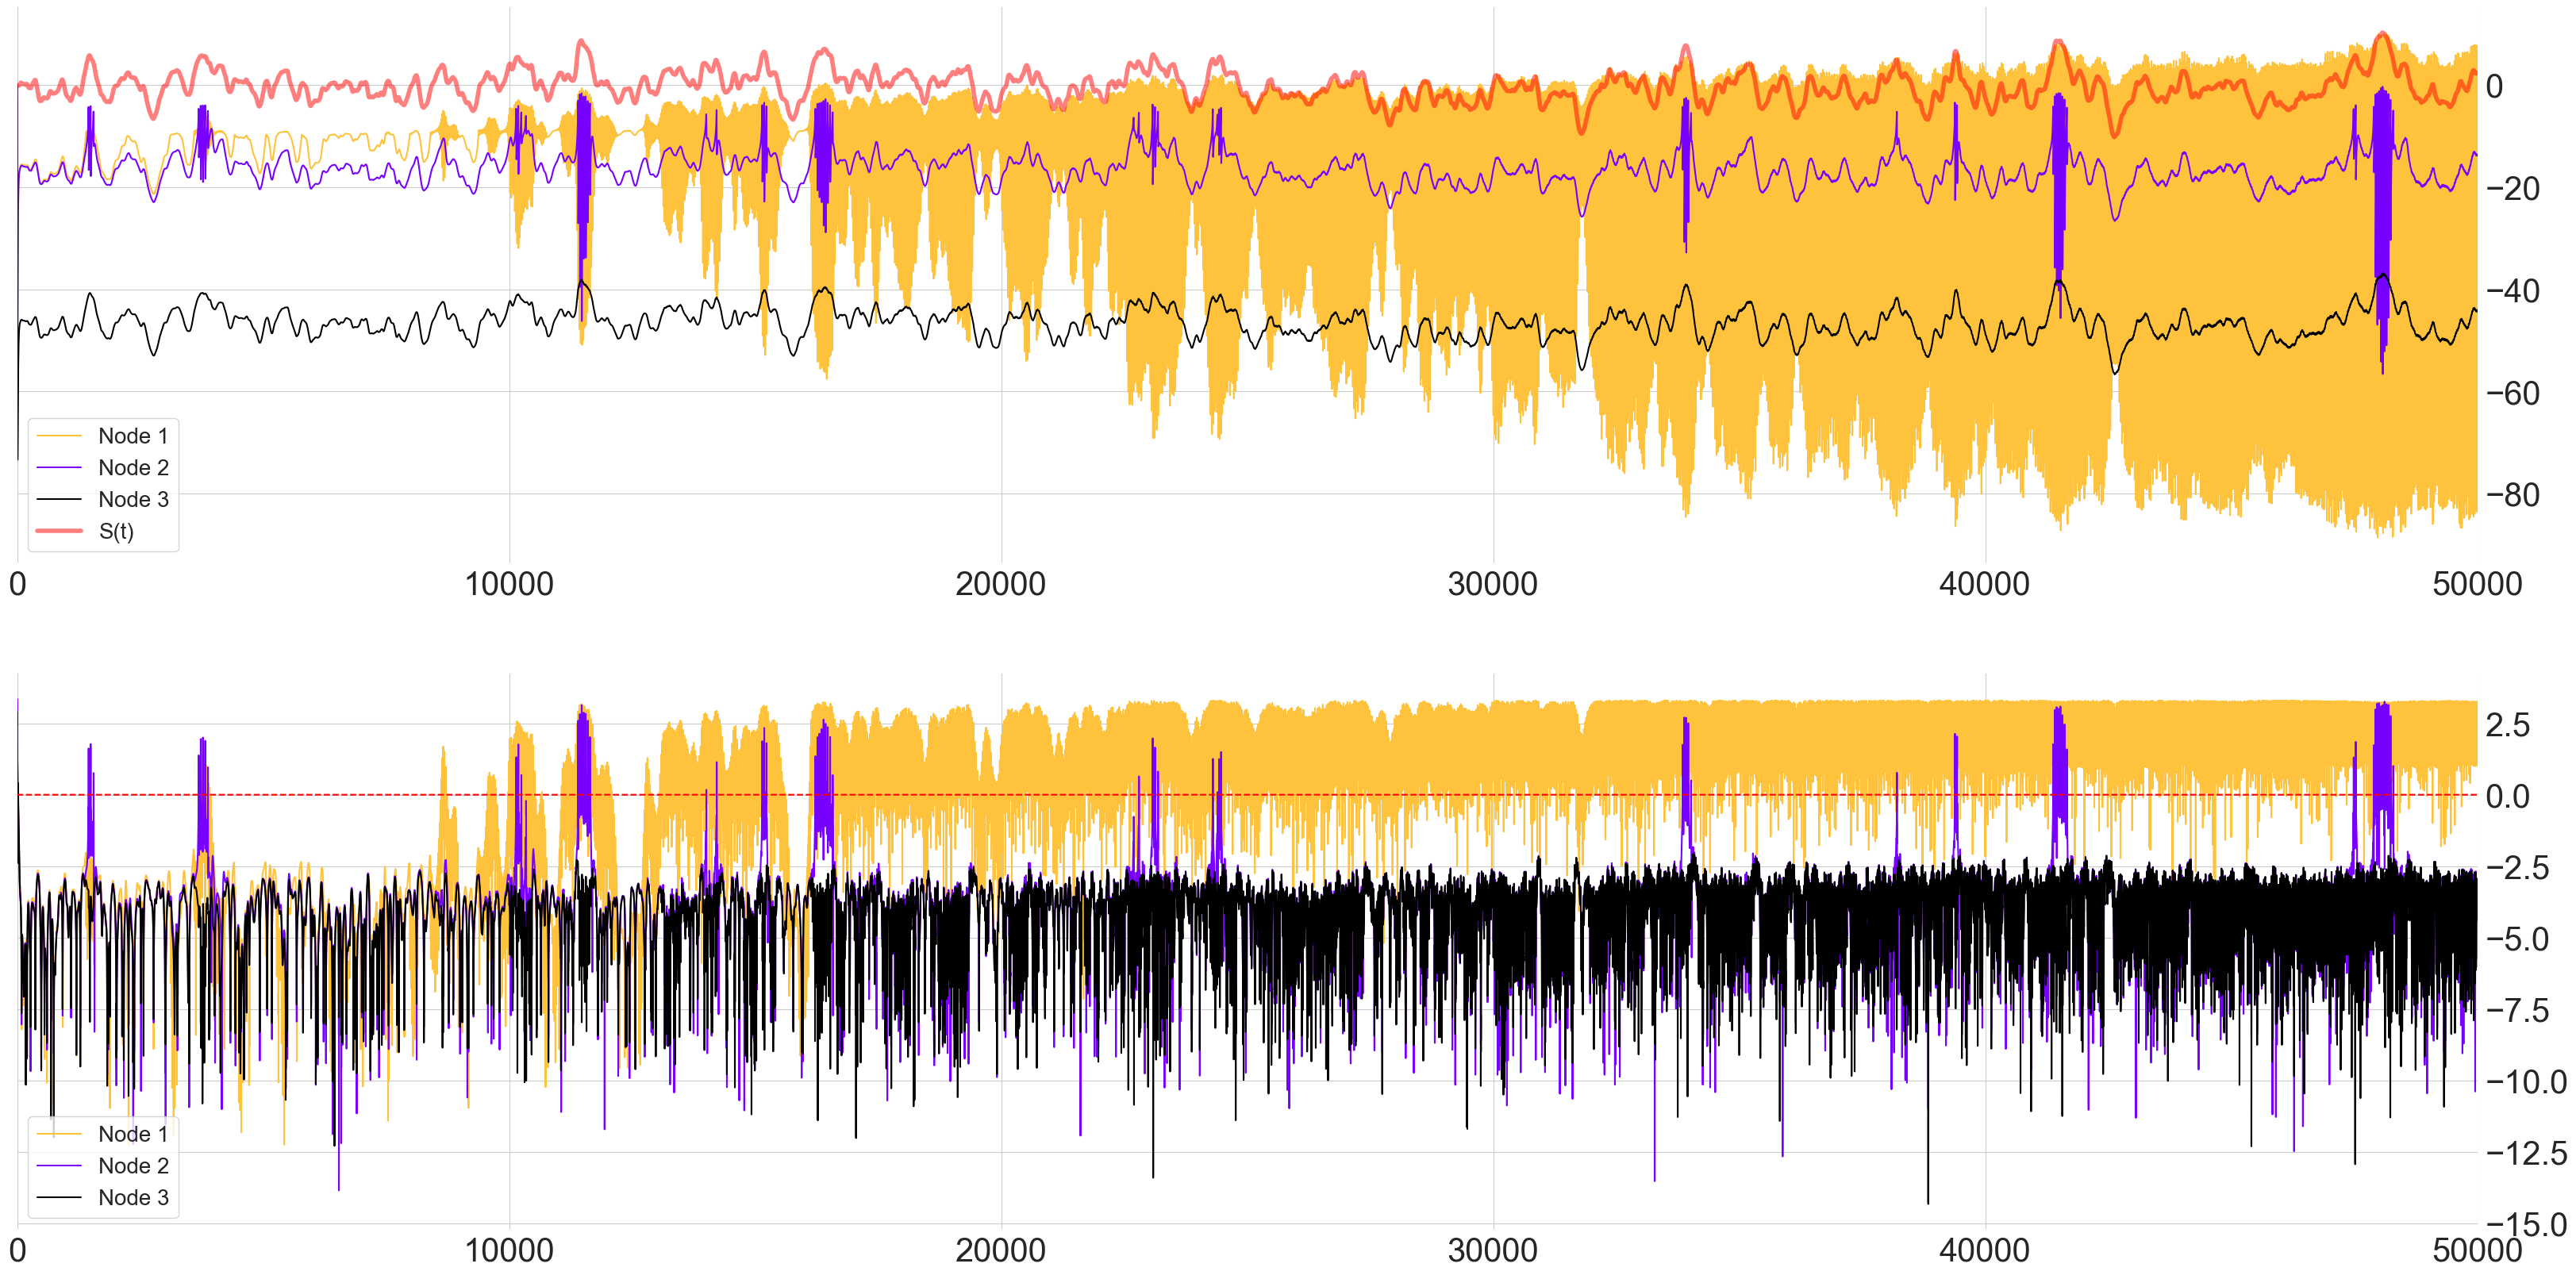

In [15]:
colormap = plt.cm.gist_ncar
plt.figure(figsize=(40,20))
plt.rcParams.update({'font.size': 30})

plt.subplot(2, 1, 1)
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.gnuplot2_r(np.linspace(0.2, 1, N))))
for i in range(N):
    plt.plot(time, ue[i][:], label = f'Node {i+1:01d}')

plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
plt.plot(time, perturbations_1 / gamma, color='red',  linewidth=4, alpha=0.5, label = 'S(t)')
for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
if N <= 4:
    plt.legend(loc = 'lower left', fontsize=20)
plt.xlim(0, T) 

t_prime = time[: T - 1]
plt.subplot(2, 1, 2)
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.gnuplot2_r(np.linspace(0.2, 1, N))))
for i in range(N):
  plt.plot(t_prime, np.log(np.abs(np.diff((ue[i][0 : T])))), label = f'Node {i+1:01d}')
plt.plot(t_prime,np.zeros(T - 1),"--", color='red')
for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
plt.tick_params(axis='y', which='both', labelleft=False, labelright=True) 
plt.xlim(0, T) 
if N <= 4:
    plt.legend(loc = 'lower left', fontsize = 20)

In [16]:
with open(os.path.join(results_dir, 'parameters.json'), 'w+') as output_file:
    json.dump(write_json, output_file, indent = 3)

## Sub-Sample Nodes
In this section, we will sub-sample the nodes of the original network to analyze whether the same stability conditions can be seen in with the reduced network. During the process:

1. The control node is kept constant (Node no. 0)
2. Node coupling values between the selected nodes are kept the same.
3. Heterogeneity parameters used for each node is kept constant.

In [17]:
sub_nodes = N
node_idx = np.arange(0, N)
# node_idx += list(np.random.choice(np.arange(1, N), size = sub_nodes - 1, replace = False))

weight_scales = [1, 5, 10, 20, 25]

C:\Users\kgaya\AppData\Local\Temp\ipykernel_9396\3118493370.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * (x - thresh)))


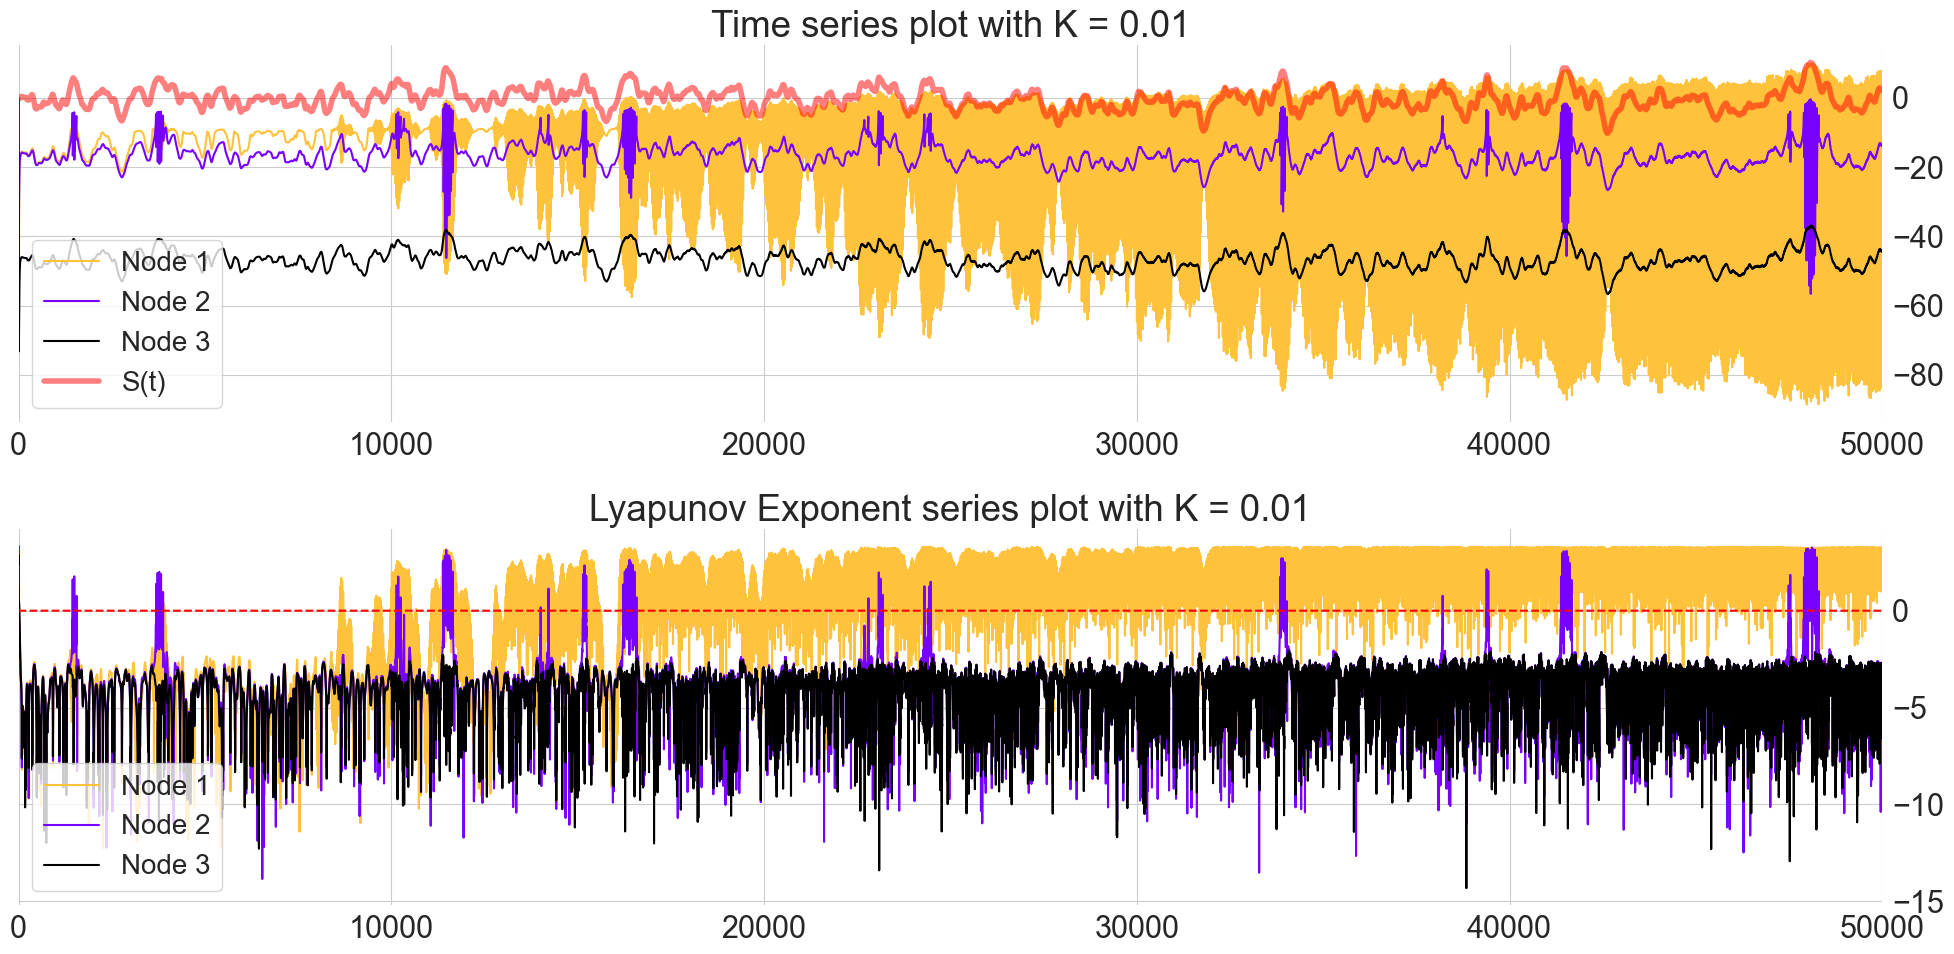

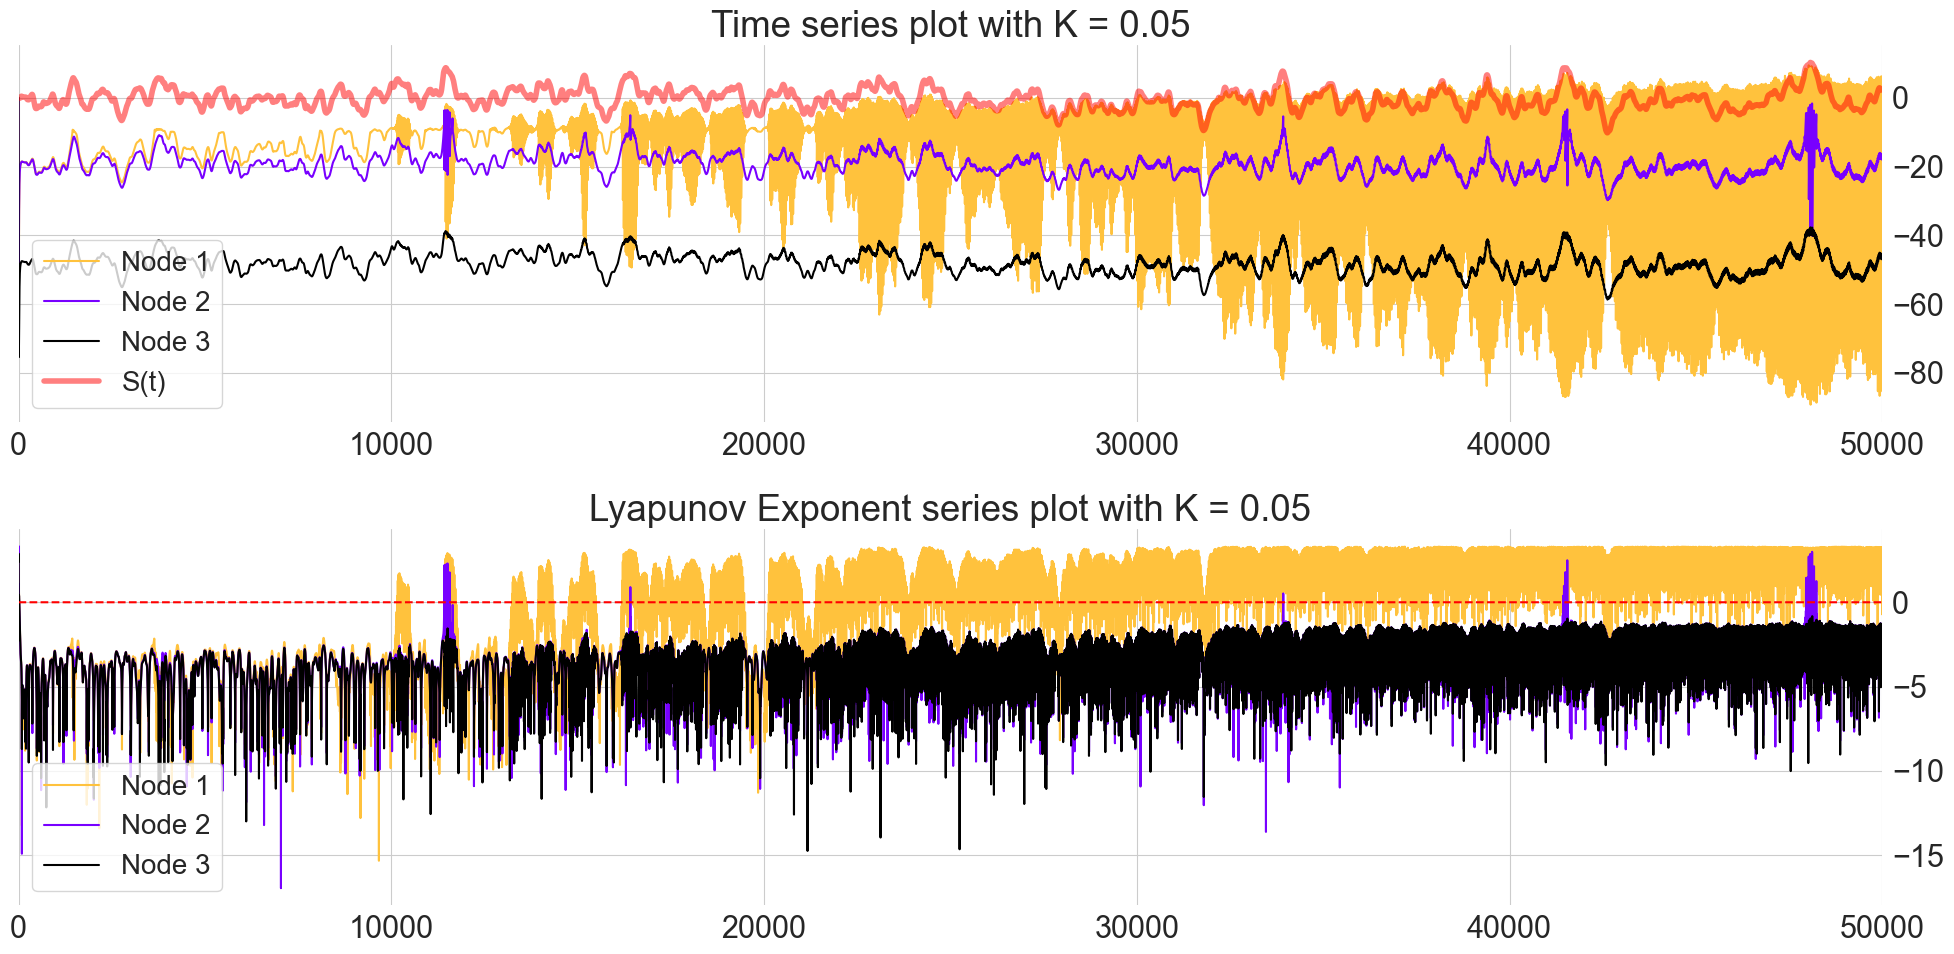

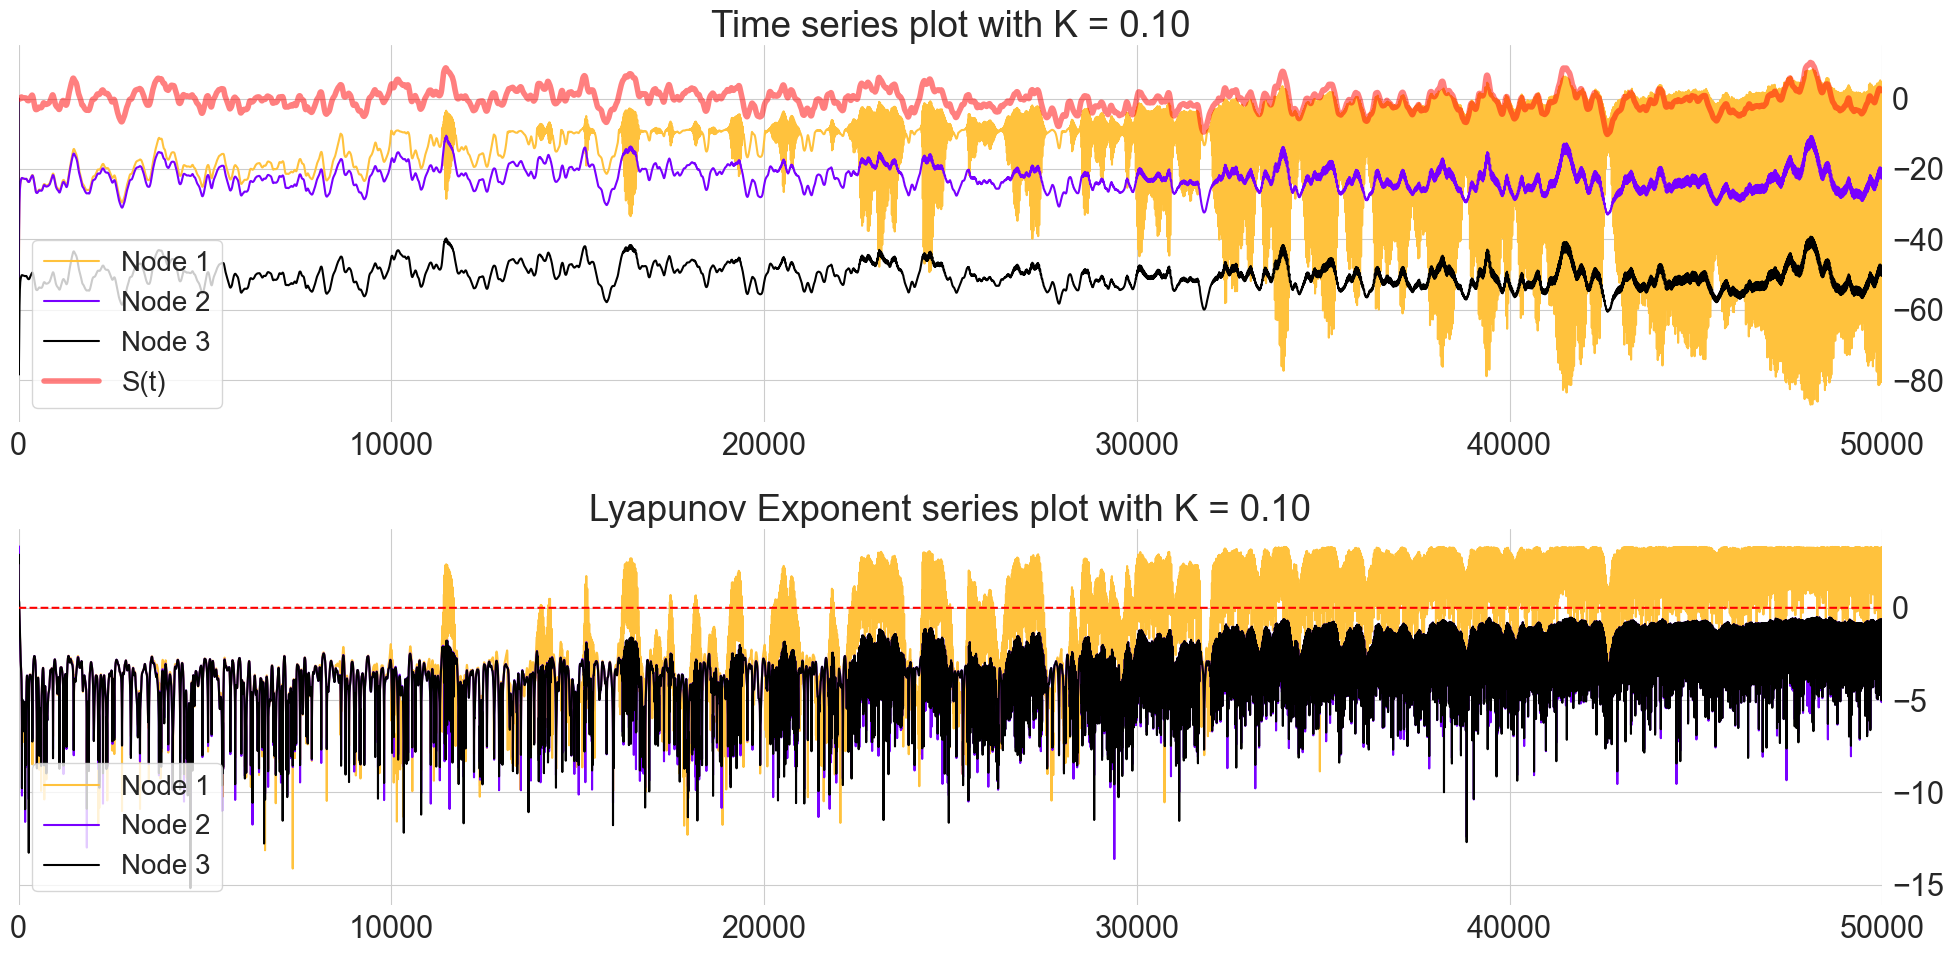

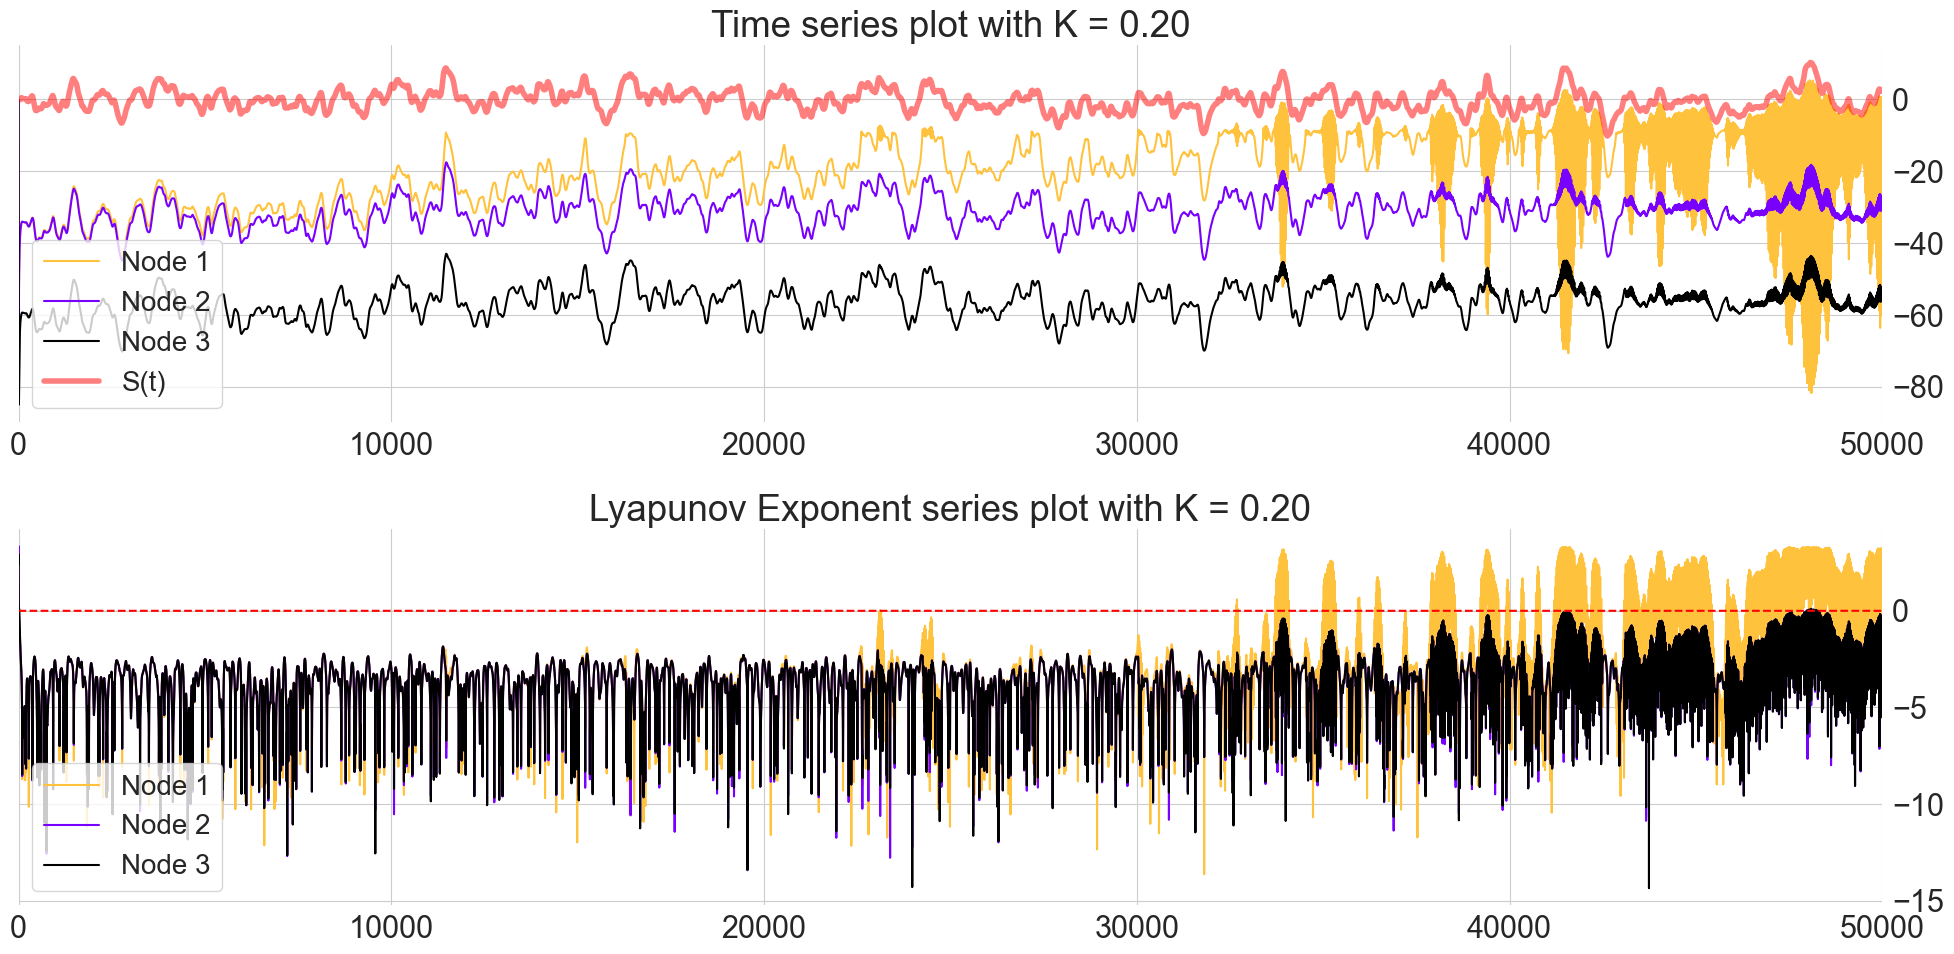

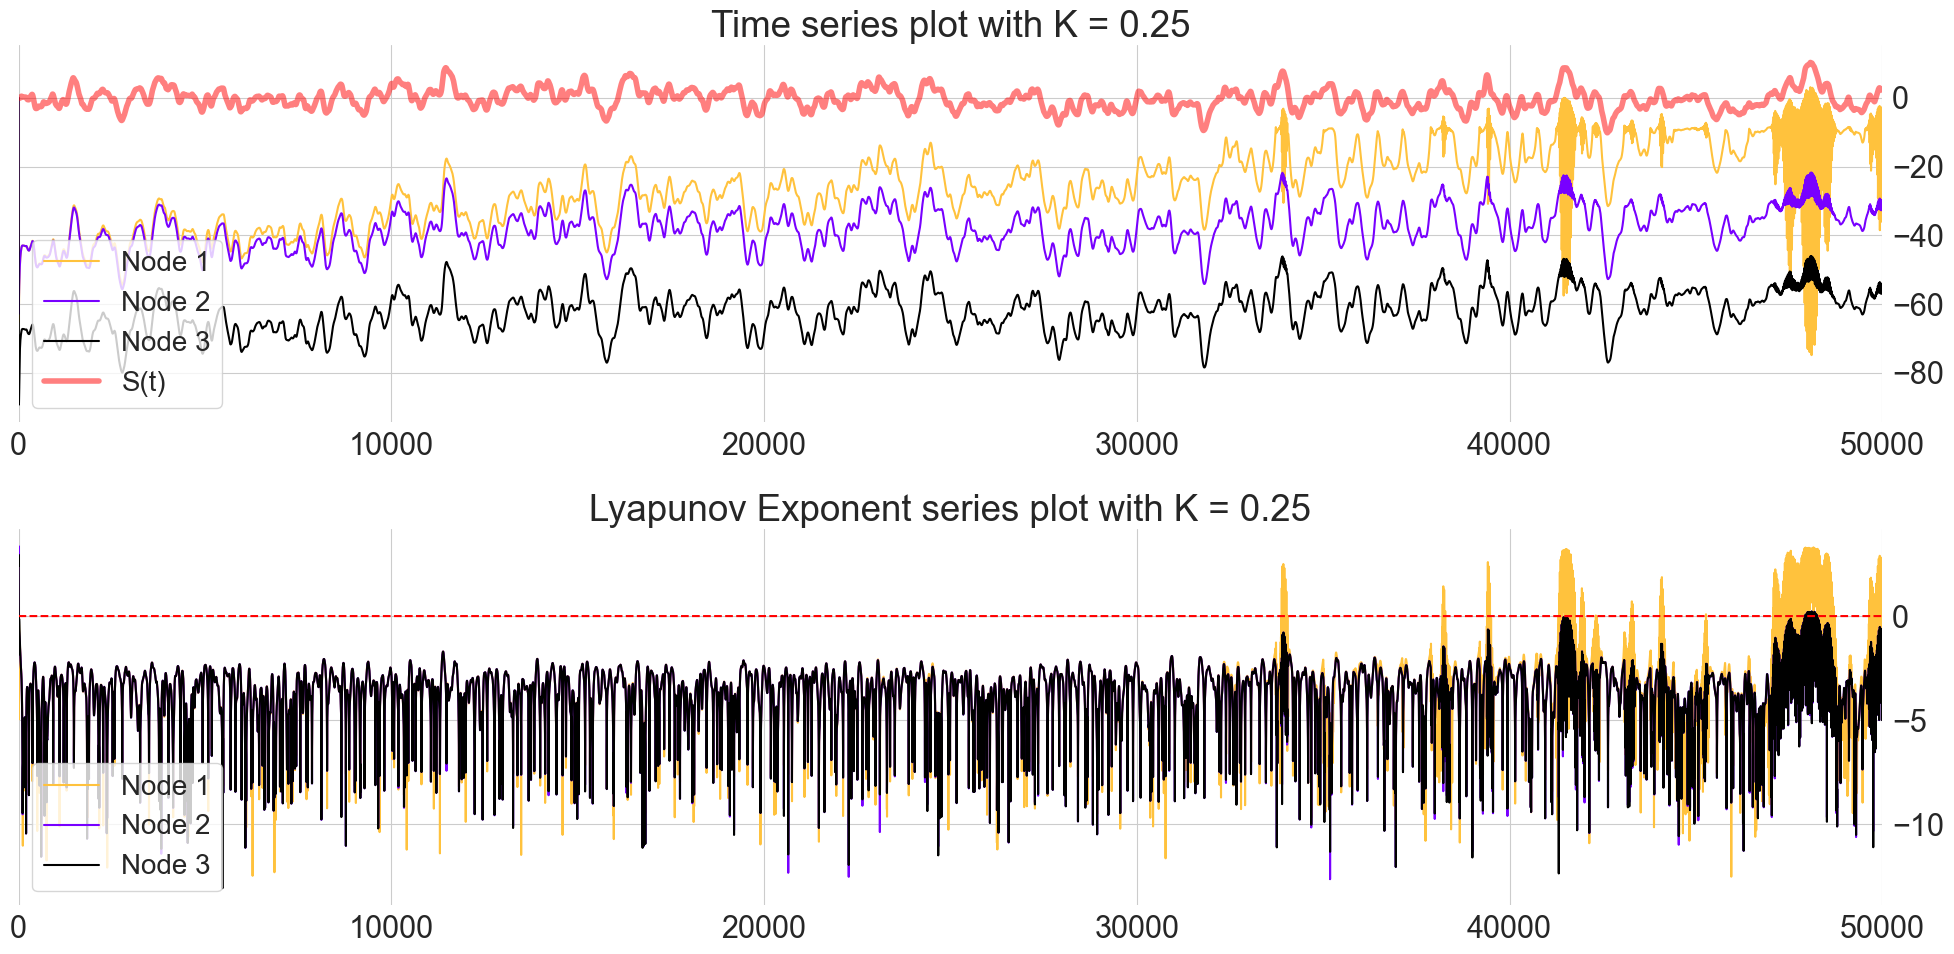

In [18]:
for weight_scale in weight_scales:
    W_bar = W[node_idx, :]
    W_bar = W_bar[:, node_idx]
    W_bar = W_bar * weight_scale

    ue_bar = np.zeros((sub_nodes, T))
    ui_bar = np.zeros((sub_nodes, T))

    # TODO: Can we have heterogeneity in mean firing thresh for each population?
    thresh_e_sig = 0.0      # mean firing threshold for E-subpopulation
    thresh_i_sig = 0.0      # mean firing threshold for I-subpopulation
    
    thresh_e = np.zeros(N)
    thresh_i = np.zeros(N)
    
    #Euler integration
    for i in range(sub_nodes):
      ue_bar[i][0] = 0.05 * np.random.normal(0, 1)
      ui_bar[i][0] = 0.05 * np.random.normal(0, 1)
    
    for t in range(T - 1):
      for i in range(sub_nodes):
        _sum_i = 0
        _sum_e = np.matmul(W_bar[i, :], ue_bar[:, t])
        _sum_e += perturbations_1[t] / gamma
        
        if (i == 0):
            _sum_e += perturbations_3[t] / gamma    # Adding local perturbation to the Node 1
        
        _sum_e += wee * F(ue_bar[i][t], beta, thresh_e[node_idx[i]], gamma, sigma_e[node_idx[i]]) \
                  + wie * F(ui_bar[i][t], beta, thresh_i[node_idx[i]], gamma, sigma_i[node_idx[i]])        
        ue_bar[i][t + 1] = ue_bar[i][t] + dt / tau_e * (-ue_bar[i][t] + _sum_e + e_bias) \
                       + np.sqrt(2 * D * dt / tau_e) * np.random.normal(0, 1)
        
        _sum_i += wei * F(ue_bar[i][t], beta, thresh_e[node_idx[i]], gamma, sigma_e[node_idx[i]]) \
                  + wii * F(ui_bar[i][t], beta, thresh_i[node_idx[i]], gamma, sigma_i[node_idx[i]])
        ui_bar[i][t + 1] = ui_bar[i][t] + dt / tau_i * (-ui_bar[i][t] + _sum_i + i_bias) \
                       + np.sqrt(2 * D * dt / tau_i) * np.random.normal(0, 1)
            
    # Visualization in time and Lyapunov exponents
    fig_path = os.path.join(results_dir, f'lyapunov_slow_mod_N0={Noise}_N={sub_nodes}_coupling={weight_scale * 0.01:.2f}.png')

    colormap = plt.cm.gist_ncar
    plt.figure(figsize=(20, 10))
    plt.rcParams.update({'font.size': 22})
    
    plt.subplot(2, 1, 1)
    plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.gnuplot2_r(np.linspace(0.2, 1, N))))
    for i in range(sub_nodes):
        plt.plot(time, ue_bar[i][:], label = f'Node {i+1:01d}')
    
    plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
    plt.plot(time, perturbations_1 / gamma, color='red',  linewidth=4, alpha=0.5, label = 'S(t)')
    for pos in ['right', 'top', 'bottom', 'left']:
       plt.gca().spines[pos].set_visible(False)
    plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
    plt.xlim(0, T ) 
    plt.title(f"Time series plot with K = {weight_scale * 0.01:.2f}")
    if N <=4 :
        plt.legend(loc = 'lower left', fontsize=20)
        
    plt.subplot(2, 1, 2)
    plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.gnuplot2_r(np.linspace(0.2, 1, N))))
    for i in range(sub_nodes):
      plt.plot(t_prime, np.log(np.abs(np.diff((ue_bar[i][0 : T])))), label = f'Node {i+1:01d}')
    plt.plot(t_prime,np.zeros(T - 1),"--", color='red')
    for pos in ['right', 'top', 'bottom', 'left']:
       plt.gca().spines[pos].set_visible(False)
    plt.tick_params(axis='y', which='both', labelleft=False, labelright=True) 
    plt.xlim(0, T) 
    if N <=4 :
        plt.legend(loc = 'lower left', fontsize=20)
    plt.title(f"Lyapunov Exponent series plot with K = {weight_scale * 0.01:.2f}")
    plt.savefig(fig_path, dpi = 600)
    plt.tight_layout()
    plt.show()